# Model Analysis & Visualization

This notebook provides a comprehensive visual analysis of the barbershop no-show prediction model.  
Sections:
1. **Data Overview** - shape, types, class balance
2. **Feature Distributions** - histograms per class
3. **Correlation Heatmap** - feature-to-feature & feature-to-target
4. **Feature Importance** - Random Forest built-in + permutation importance
5. **Confusion Matrices** - side-by-side across experiments
6. **ROC & Precision-Recall Curves**
7. **Threshold Tuning** - F1 / Precision / Recall vs. threshold
8. **Experiment Comparison Dashboard**

In [20]:
import sys, os
sys.path.append('..')

os.getcwd()


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, auc
)

from src.data.generate import generate
from src.data.preprocess import preprocess
from src.config.config import FEATURES, TARGET

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})
PALETTE = ['#2ecc71', '#e74c3c']  # Show=green, No-Show=red
print('Setup complete')

Setup complete


In [21]:
N_ROWS = 10_000
SEED   = 42

raw_df = generate(n=N_ROWS, seed=SEED, save=False)
df     = preprocess(raw_df, save=False)

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Total rows:  {len(df):,}')
print(f'Train size:  {len(X_train):,} | Test size: {len(X_test):,}')
print(f'No-show rate (overall): {y.mean():.2%}')
print(f'No-show rate (test):    {y_test.mean():.2%}')

Total rows:  10,000
Train size:  8,000 | Test size: 2,000
No-show rate (overall): 71.52%
No-show rate (test):    71.50%


---
## 1 · Data Overview

In [22]:
print('=== Processed DataFrame Info ===')
print(f'Shape: {df.shape}')
print(f'\nColumn types:\n{df[FEATURES + [TARGET]].dtypes}')
print(f'\nDescriptive stats:')
df[FEATURES + [TARGET]].describe().round(3)

=== Processed DataFrame Info ===
Shape: (10000, 14)

Column types:
day_of_week                 int8
hour_of_day              float64
lead_time_days           float64
is_returning_customer       int8
booking_channel             int8
service_type                int8
reminder_sent               int8
barber_id                  int64
previous_no_shows        float64
total_previous_visits    float64
no_show                    int64
dtype: object

Descriptive stats:


,day_of_week,hour_of_day,lead_time_days,is_returning_customer,booking_channel,service_type,reminder_sent,barber_id,previous_no_shows,total_previous_visits,no_show
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,2.498,0.496,0.380,0.652,0.755,0.903,0.704,1.263,0.316,0.343,0.715
std,1.721,0.319,0.262,0.476,0.764,0.702,0.457,1.043,0.401,0.341,0.451
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,1.000,0.222,0.143,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,3.000,0.444,0.357,1.000,1.000,1.000,1.000,1.000,0.000,0.263,1.000
75%,4.000,0.778,0.571,1.000,1.000,1.000,1.000,2.000,0.500,0.632,1.000
max,5.000,1.000,1.000,1.000,2.000,2.000,1.000,3.000,1.000,1.000,1.000


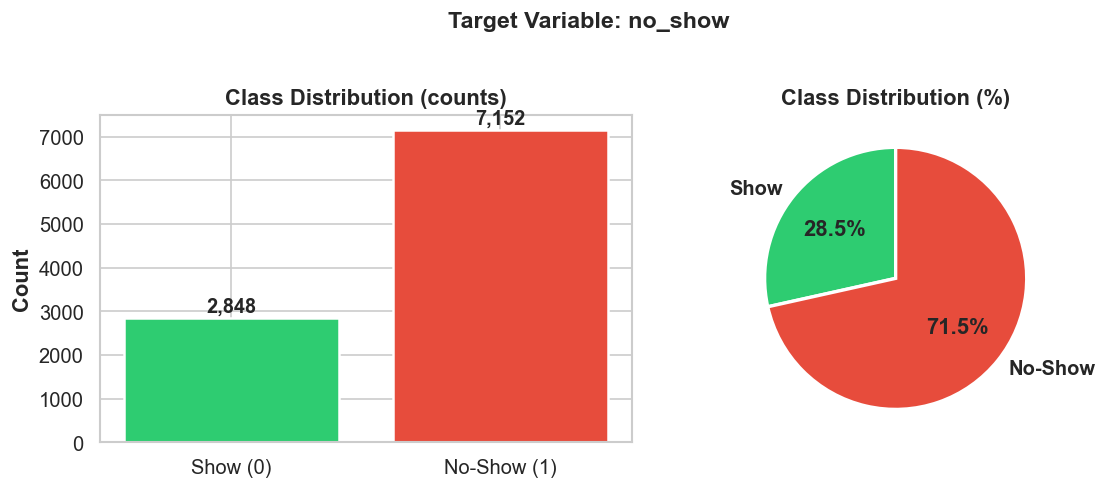

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
counts = y.value_counts().sort_index()
bars = axes[0].bar(['Show (0)', 'No-Show (1)'], counts.values, color=PALETTE, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Class Distribution (counts)')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values, labels=['Show', 'No-Show'], colors=PALETTE,
            autopct='%1.1f%%', startangle=90, textprops={'fontweight': 'bold'},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (%)')

fig.suptitle('Target Variable: no_show', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 2 · Feature Distributions by Class

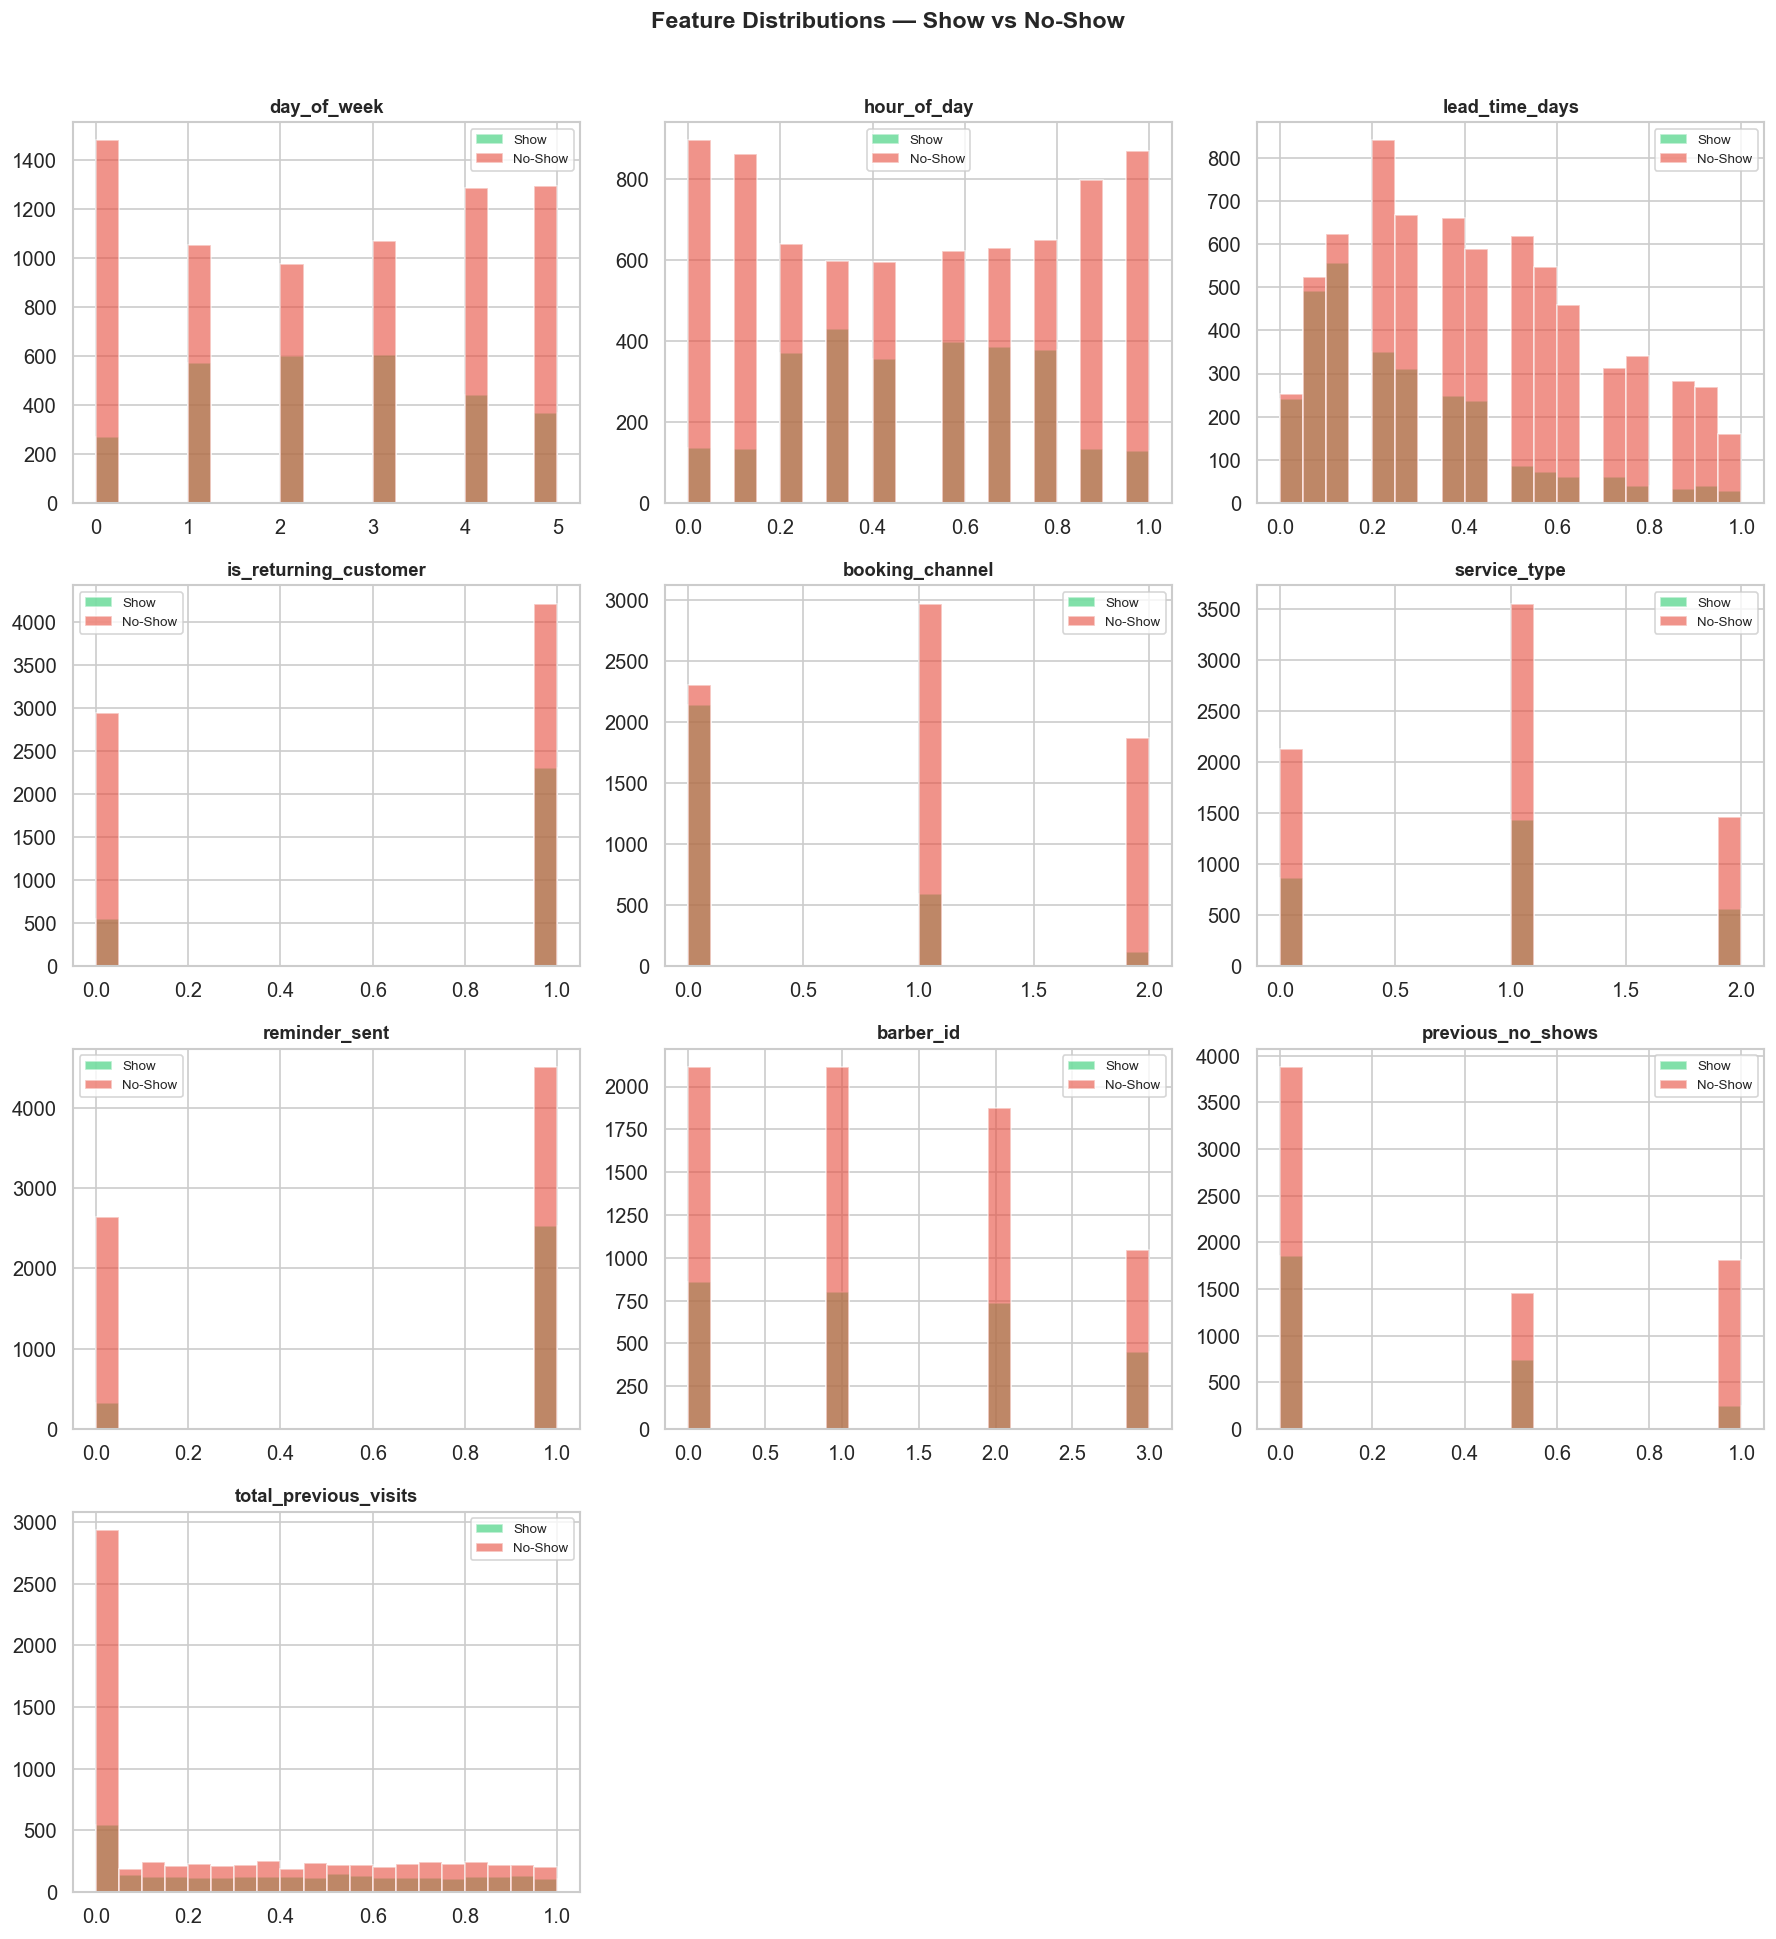

In [24]:
n_features = len(FEATURES)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    for label, color in zip([0, 1], PALETTE):
        subset = df[df[TARGET] == label][feat]
        ax.hist(subset, bins=20, alpha=0.6, color=color,
                label='Show' if label == 0 else 'No-Show', edgecolor='white')
    ax.set_title(feat, fontsize=11)
    ax.legend(fontsize=8)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions — Show vs No-Show', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 3 · Correlation Heatmap

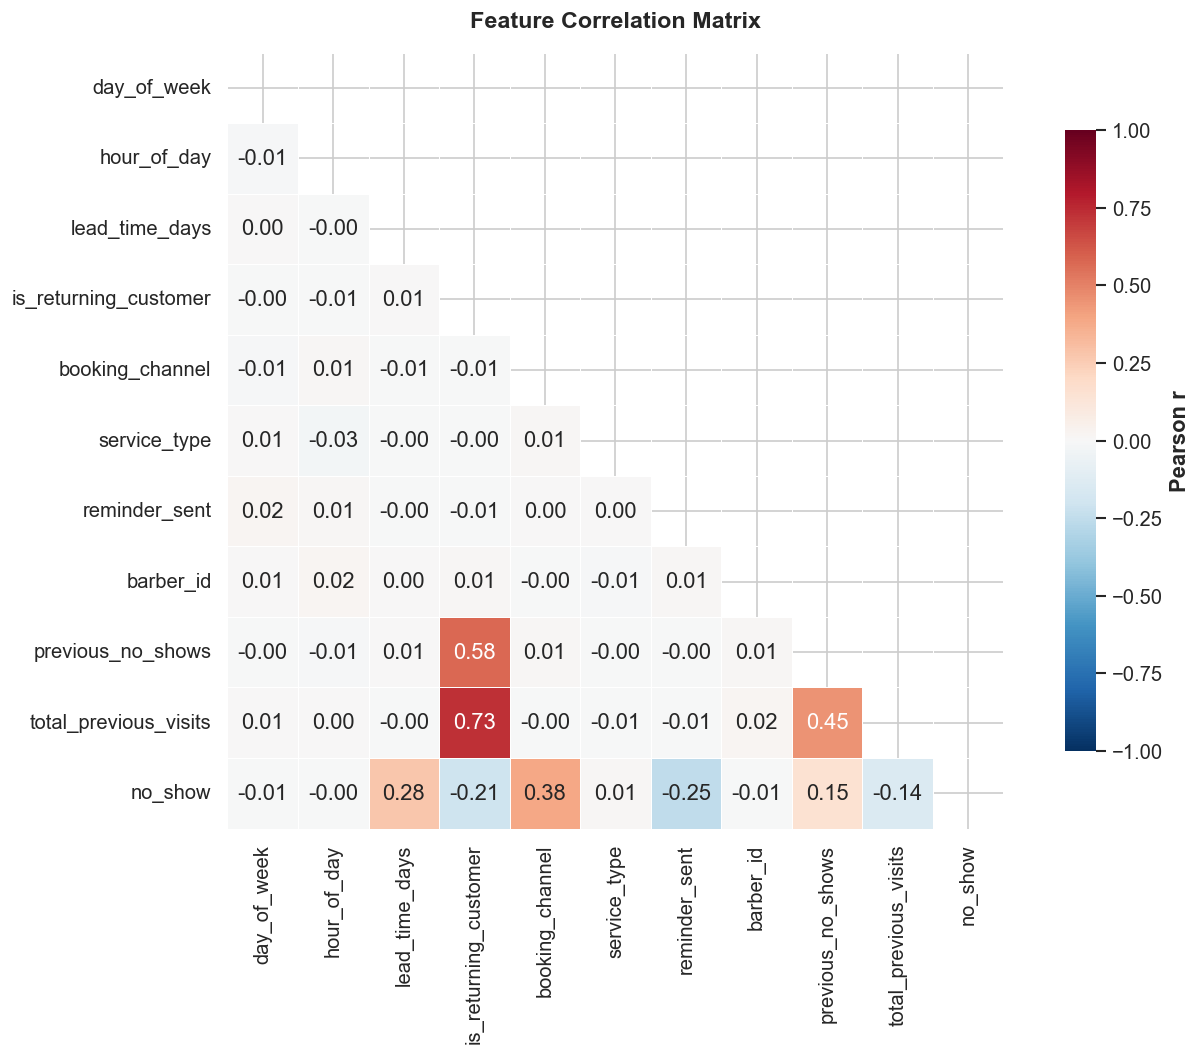


=== Correlation with no_show (sorted) ===
  booking_channel              +0.384  ███████████████
  lead_time_days               +0.277  ███████████
  previous_no_shows            +0.154  ██████
  service_type                 +0.009  
  hour_of_day                  -0.003  
  barber_id                    -0.006  
  day_of_week                  -0.008  
  total_previous_visits        -0.143  █████
  is_returning_customer        -0.209  ████████
  reminder_sent                -0.254  ██████████


In [25]:
corr = df[FEATURES + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Show correlation with target specifically
print('\n=== Correlation with no_show (sorted) ===')
target_corr = corr[TARGET].drop(TARGET).sort_values(ascending=False)
for feat, val in target_corr.items():
    bar = '█' * int(abs(val) * 40)
    sign = '+' if val > 0 else '-'
    print(f'  {feat:28s} {sign}{abs(val):.3f}  {bar}')

---
## 4 · Feature Importance

In [26]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred  = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print(f'Baseline RF — Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Baseline RF — F1:       {f1_score(y_test, y_pred):.4f}')
print(f'Baseline RF — ROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}')

Baseline RF — Accuracy: 0.9910
Baseline RF — F1:       0.9937
Baseline RF — ROC-AUC:  0.9997


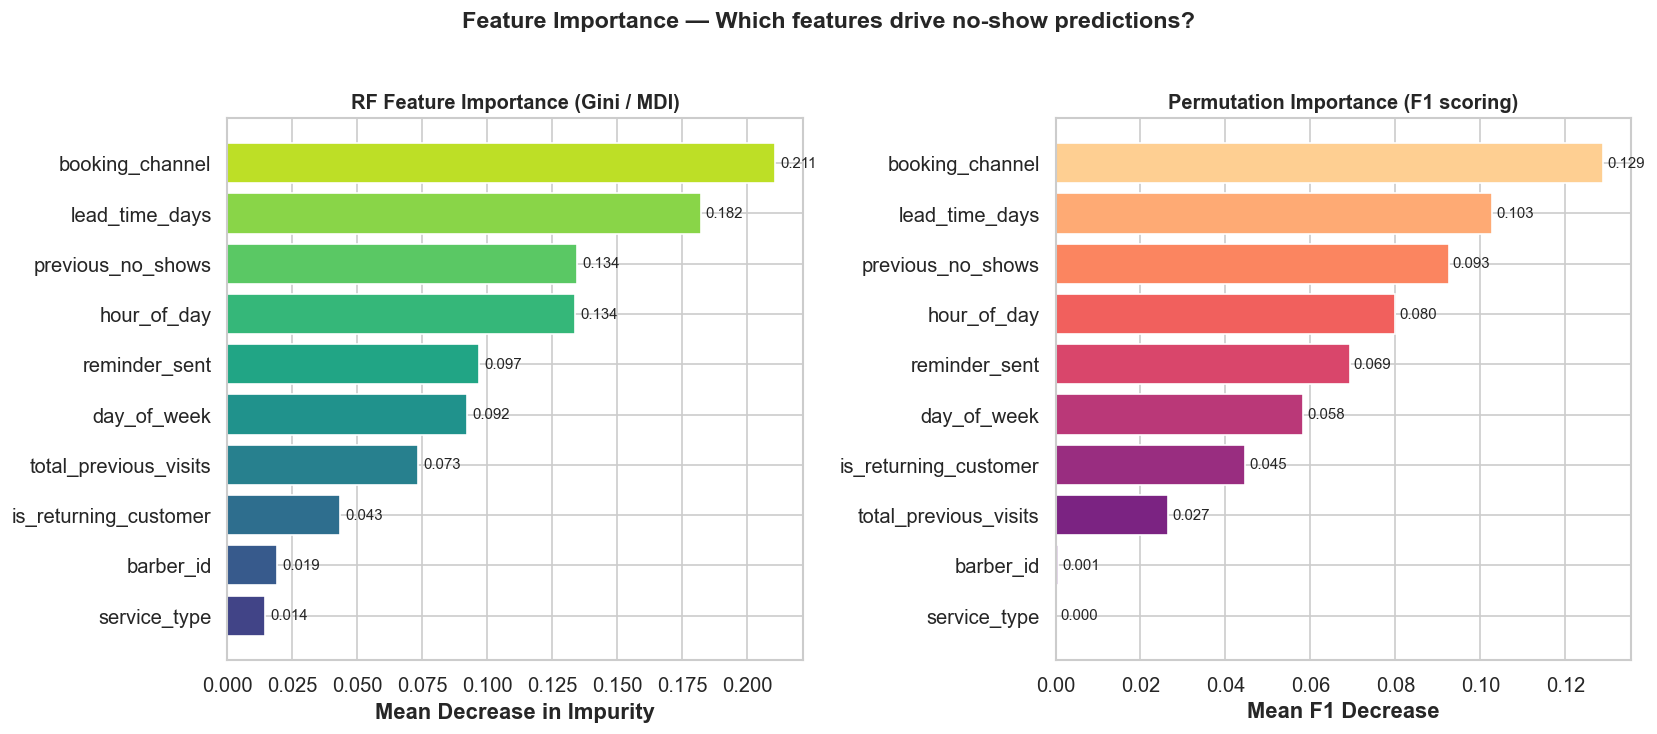

In [27]:
# 1) Built-in (mean decrease in impurity)
gini_imp = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()

# 2) Permutation importance (model-agnostic, more reliable)
perm_result = permutation_importance(
    rf_model, X_test, y_test, n_repeats=15, random_state=SEED, scoring='f1', n_jobs=-1
)
perm_imp = pd.Series(perm_result.importances_mean, index=FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gini importance
colors_gini = plt.cm.viridis(np.linspace(0.2, 0.9, len(gini_imp)))
axes[0].barh(gini_imp.index, gini_imp.values, color=colors_gini, edgecolor='white')
axes[0].set_title('RF Feature Importance (Gini / MDI)', fontsize=12)
axes[0].set_xlabel('Mean Decrease in Impurity')
for i, (val, name) in enumerate(zip(gini_imp.values, gini_imp.index)):
    axes[0].text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

# Permutation importance
colors_perm = plt.cm.magma(np.linspace(0.2, 0.9, len(perm_imp)))
axes[1].barh(perm_imp.index, perm_imp.values, color=colors_perm, edgecolor='white')
axes[1].set_title('Permutation Importance (F1 scoring)', fontsize=12)
axes[1].set_xlabel('Mean F1 Decrease')
for i, (val, name) in enumerate(zip(perm_imp.values, perm_imp.index)):
    axes[1].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)

fig.suptitle('Feature Importance — Which features drive no-show predictions?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5 · Confusion Matrix

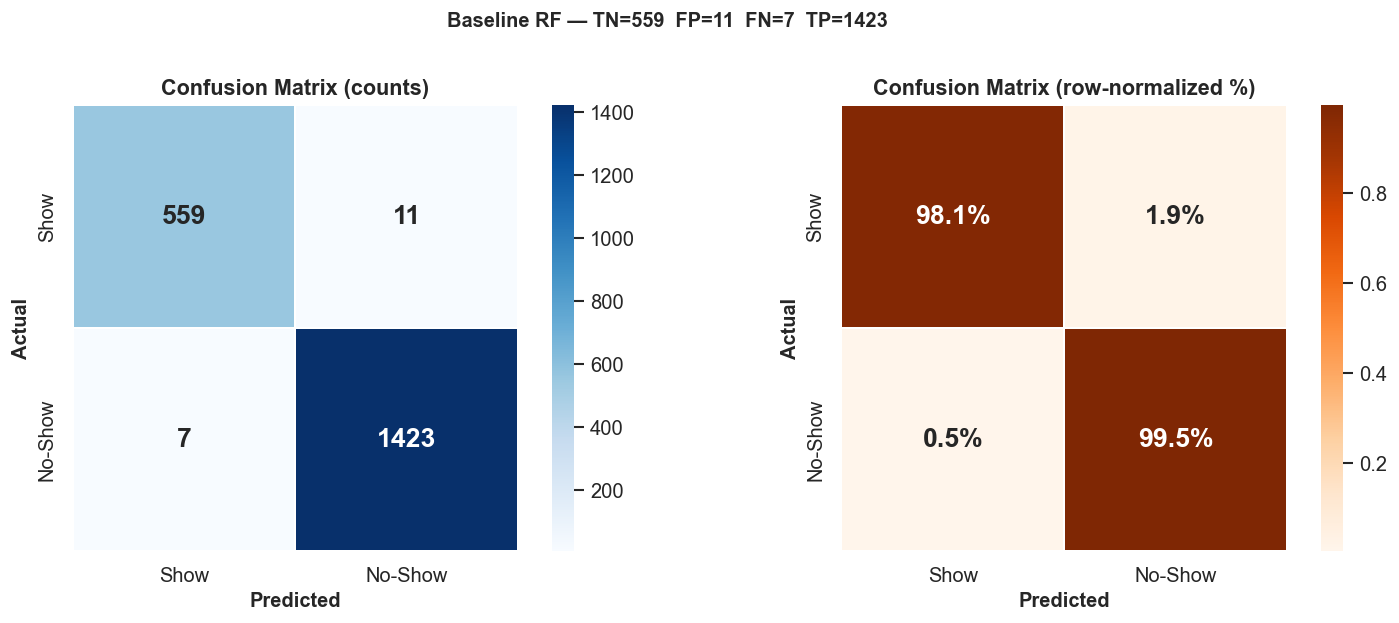


Detailed report:
              precision    recall  f1-score   support

        Show       0.99      0.98      0.98       570
     No-Show       0.99      1.00      0.99      1430

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [28]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=['Show', 'No-Show'], yticklabels=['Show', 'No-Show'],
            annot_kws={'size': 16, 'weight': 'bold'}, linewidths=1, ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Confusion Matrix (counts)', fontsize=13)

# Normalized (percentages)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_pct, annot=True, fmt='.1%', cmap='Oranges', square=True,
            xticklabels=['Show', 'No-Show'], yticklabels=['Show', 'No-Show'],
            annot_kws={'size': 16, 'weight': 'bold'}, linewidths=1, ax=axes[1])
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Confusion Matrix (row-normalized %)', fontsize=13)

tn, fp, fn, tp = cm.ravel()
fig.suptitle(f'Baseline RF — TN={tn}  FP={fp}  FN={fn}  TP={tp}',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nDetailed report:\n{classification_report(y_test, y_pred, target_names=["Show", "No-Show"])}')

---
## 6 · ROC Curve & Precision-Recall Curve

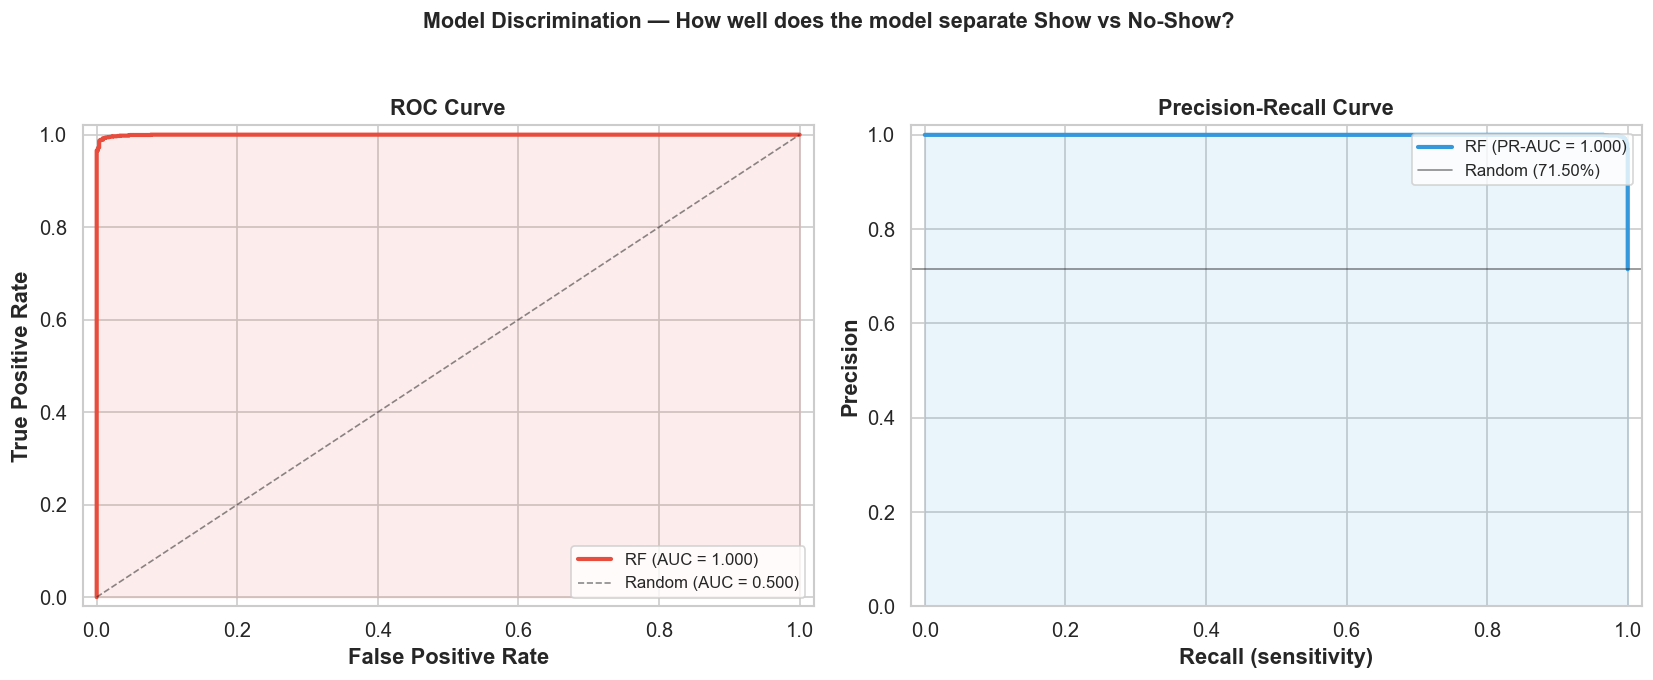

In [29]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc_val = auc(fpr, tpr)

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_proba)
pr_auc_val = auc(recall_vals, precision_vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ROC Curve
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'RF (AUC = {roc_auc_val:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.500)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontsize=13)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])

# Precision-Recall Curve
baseline_rate = y_test.mean()
axes[1].plot(recall_vals, precision_vals, color='#3498db', lw=2.5, label=f'RF (PR-AUC = {pr_auc_val:.3f})')
axes[1].axhline(y=baseline_rate, color='k', linestyle='-', lw=1, alpha=0.5,
                label=f'Random ({baseline_rate:.2%})')
axes[1].fill_between(recall_vals, precision_vals, alpha=0.1, color='#3498db')
axes[1].set_xlabel('Recall (sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontsize=13)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].set_xlim([-0.02, 1.02])
axes[1].set_ylim([0, 1.02])

fig.suptitle('Model Discrimination — How well does the model separate Show vs No-Show?',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()